In [1]:
#Telco Customer Churn Prediction Using Machine Learning

In [2]:
%pip install seaborn
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [4]:
# Data Loading

In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.drop("customerID", axis=1, inplace=True)

In [10]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
# Data Cleaning

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)  

In [14]:
df['Churn'] = df['Churn'].map({'Yes':1 , 'No':0})

In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
# Exploratory Data Analysis (EDA)

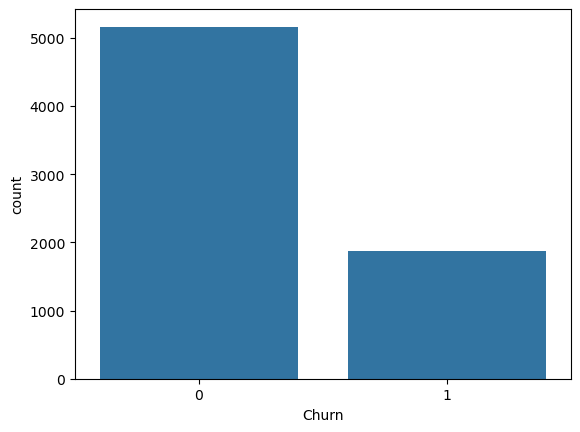

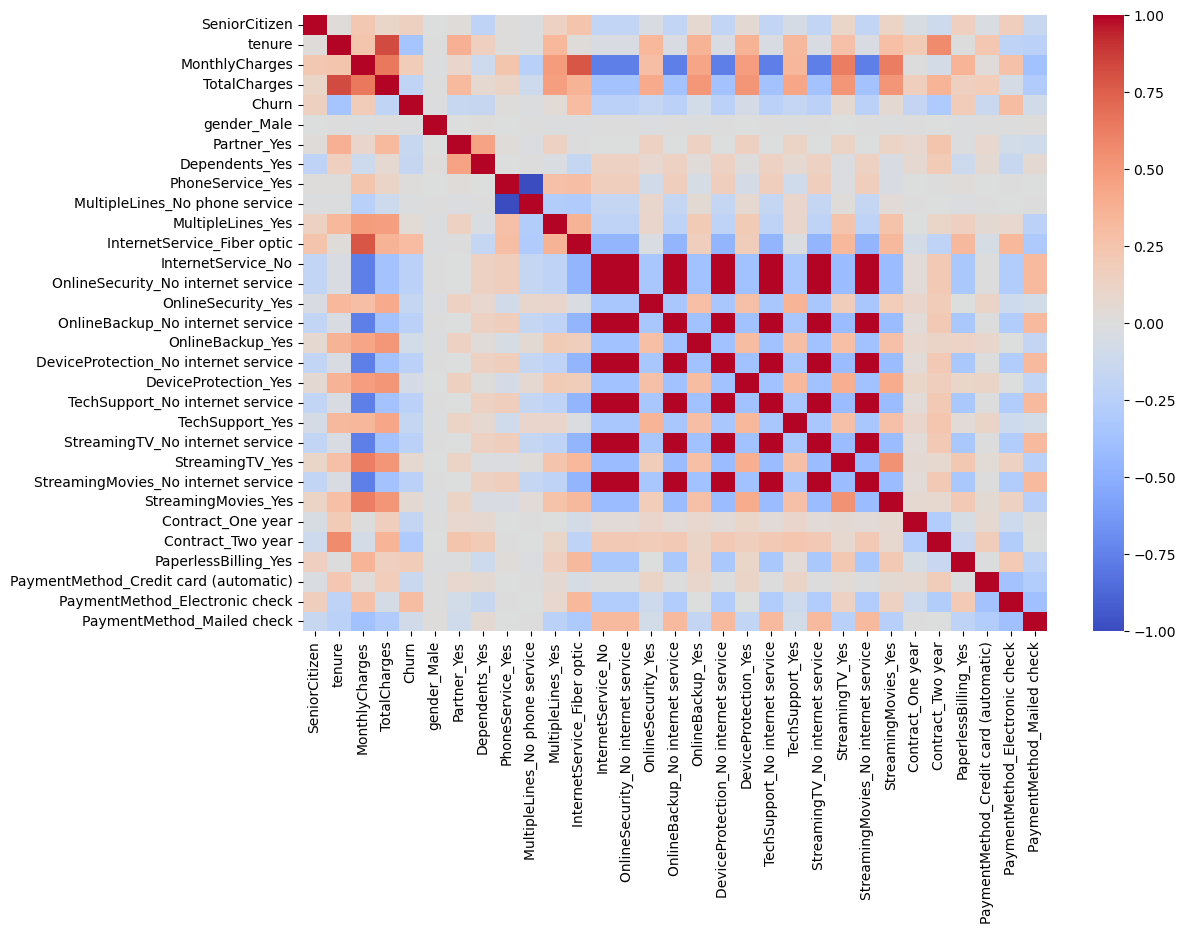

In [17]:
# Churn distribution
sns.countplot(x='Churn', data=df)
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [18]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [19]:
x = df.drop('Churn', axis=1)
y = df['Churn']

In [20]:
# Data Preprocessing

In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42, stratify=y)

In [22]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


In [23]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [24]:
# Model Training

In [25]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
pred_lr = lr.predict(x_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Logistic Regression
Accuracy: 0.7661691542288557
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1033
           1       0.55      0.65      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.77      1407



In [26]:
rf = RandomForestClassifier(n_estimators=200, random_state=42,)
rf.fit(x_train, y_train)
pred_rf = rf.predict(x_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Random Forest
Accuracy: 0.7803837953091685
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.59      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [27]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
pred_dt = dt.predict(x_test)
print("=== Decision Tree ===")
print(classification_report(y_test, pred_dt))

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      1033
           1       0.47      0.52      0.49       374

    accuracy                           0.71      1407
   macro avg       0.64      0.65      0.65      1407
weighted avg       0.72      0.71      0.72      1407



In [28]:
# Model Comparison

In [29]:
results = {
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_dt)
    ],
    "F1 Score": [
        classification_report(y_test, pred_lr, output_dict=True)['1']['f1-score'],
        classification_report(y_test, pred_rf, output_dict=True)['1']['f1-score'],
        classification_report(y_test, pred_dt, output_dict=True)['1']['f1-score']
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr.predict_proba(x_test)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(x_test)[:,1]),
        roc_auc_score(y_test, dt.predict_proba(x_test)[:,1])
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.766169,0.595326,0.816804
1,Random Forest,0.780384,0.590728,0.817193
2,Decision Tree,0.714996,0.490470,0.652353


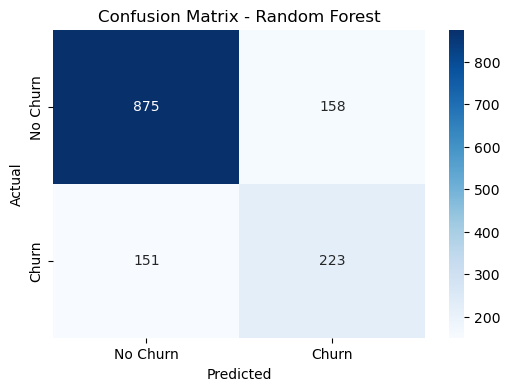

Confusion Matrix:
 [[875 158]
 [151 223]]


In [30]:
y_pred = rf.predict(x_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize with heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Optional: print the raw numbers
print("Confusion Matrix:\n", cm)

Text(0.5, 0, 'Feature importance')

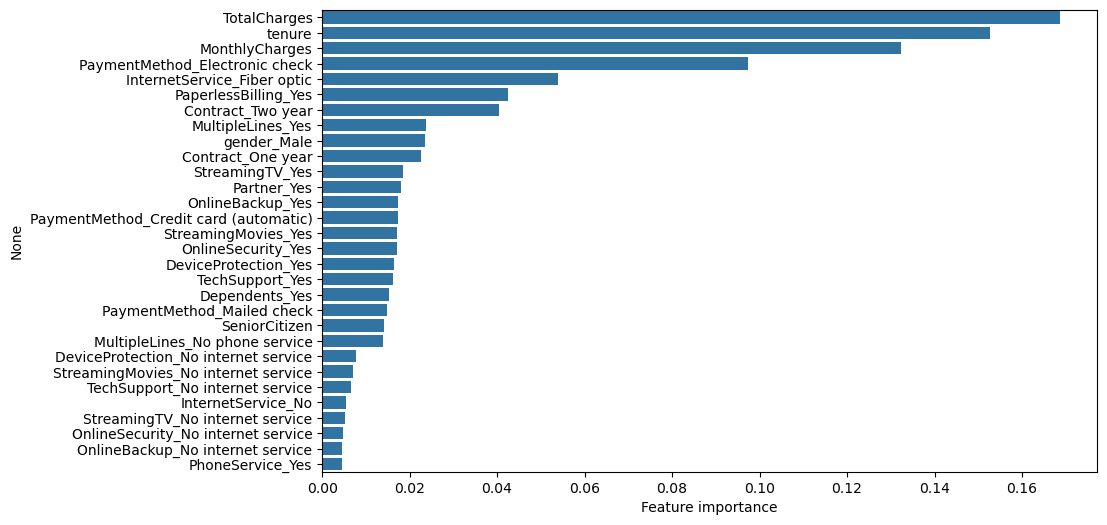

In [31]:
feature_importances = rf.feature_importances_
feature_names = x.columns

sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances[sorted_idx], y=feature_names[sorted_idx])
plt.xlabel("Feature importance")